# Fast approximation of a cylinder magnet's B-field

**Goal:** a magnet is a 6mm-diameter x 6mm-tall cylinder, magnetized along its
axis. We want a *fast* (non-magpylib-call) approximation of its B-field over
a rectangular region below it, good enough for quick repeated evaluation.

**Region of interest:** originally a 10x10x10mm cube with its top face
centered on the magnet's bottom face. We found that the field very close to
the magnet's circular edge (radius 3mm, right at the top face) is a real
physical singularity that breaks a single smooth polynomial fit. So here we
**crop the top 2mm off the box**, leaving a 10 (x) x 10 (y) x 8 (z) mm region
that starts 2mm below the magnet face. This keeps us clear of the edge
singularity and (as shown below) makes the fit dramatically more accurate.

**Approach:** since the magnet is axisymmetric, the field has no
phi-dependence and no B_phi component. We exploit this by fitting an
**axisymmetric harmonic polynomial** (regular solid harmonics in cylindrical
coordinates) rather than a generic 3D Taylor series -- fewer coefficients,
and it automatically satisfies Maxwell's equations (div B = 0, curl B = 0)
in the source-free region.


In [1]:
import time
import numpy as np
import scipy
import sympy as sp
import matplotlib.pyplot as plt
import magpylib as magpy

np.set_printoptions(suppress=True)


In [2]:
a = np.random.random((3, 3)).astype(np.float32) * 500
def hex_array_2d(arr):
    lines = []
    for row in arr:
        row_string = ", ".join(
            x.hex() +"f" for x in row.tolist()
        )
        lines.append(f"Vec3{{{row_string}}}")
    return "{\n" + ",\n".join(lines) + "\n}"

print(hex_array_2d(a))

{
Vec3{0x1.e760c80000000p+8f, 0x1.4ca5440000000p+7f, 0x1.ca62fc0000000p+8f},
Vec3{0x1.25a2c80000000p+7f, 0x1.3e62300000000p+7f, 0x1.20f8b20000000p+8f},
Vec3{0x1.6d2f280000000p+8f, 0x1.35a37e0000000p+7f, 0x1.19dc6e0000000p+6f}
}


In [3]:
a = np.random.random((3, 3)).astype(np.float32) * 500

string = "{\n"
for row in a:
    string += "{"
    for x in row:
        string += float(x).hex() + "f"
    string += "},\n"
string += "}"
print(string)

{
{0x1.7b16100000000p+3f0x1.d91a560000000p+8f0x1.de763c0000000p+8f},
{0x1.7fdf240000000p+8f0x1.94c0060000000p+8f0x1.b4341e0000000p+6f},
{0x1.dfa2260000000p+7f0x1.81f0860000000p+8f0x1.31c6ba0000000p+6f},
}


## 1. Define the magnet and the region of interest

Units throughout: millimeters for length, millitesla (mT) for field.

**Unit note (magpylib v5):** use `polarization` (mT, = remanence field Br) for
magnet strength, not `magnetization` -- that kwarg expects A/m and silently
gives a field ~1000x too weak if handed mT.


In [4]:
# --- Magnet: 6mm diameter x 6mm height cylinder, magnetized along +z ---
magnet = magpy.magnet.Cylinder(
    polarization=(0, 0, -600),   # mT (~N42 neodymium remanence). Adjust to your magnet's Br.
    dimension=(6, 6),            # (diameter, height) mm
    position=(0, 0, 3),          # center at z=3 -> bottom face sits at z=0
)

# --- Region of interest: 10x10x8mm box, cropped 2mm off the top ---
# Original cube: x,y in [-5,5], z in [-10,0] (top face touching magnet's bottom face)
# Cropped box:   x,y in [-5,5], z in [-10,-2]  (removes the 2mm layer nearest the magnet)
X_MIN, X_MAX = -5.0, 5.0
Y_MIN, Y_MAX = -5.0, 5.0
Z_TOP, Z_BOT = -2.0, -10.0   # top face now 2mm below the magnet, not touching it

Z_CENTER = (Z_TOP + Z_BOT) / 2.0   # -6.0mm; on-axis, so this is our expansion point
print(f"Box: x,y in [{X_MIN},{X_MAX}], z in [{Z_BOT},{Z_TOP}]  (center at z={Z_CENTER})")


Box: x,y in [-5.0,5.0], z in [-10.0,-2.0]  (center at z=-6.0)


## 2. Compute & visualize the true field (magpylib) over the box

Quick sanity-check plots so we can see what we're approximating.


In [5]:
# Cross-section (x-z plane at y=0), covering a bit above the box top too
nx, nz = 1200, 1200
x_line = np.linspace(-5, 5, nx)
z_line = np.linspace(-10, 2, nz)   # small margin above to show the magnet & cropped-out layer

Xs, Zs = np.meshgrid(x_line, z_line)
pts = np.stack([Xs.ravel(), np.zeros_like(Xs.ravel()), Zs.ravel()], axis=-1)

B = magnet.getB(pts).reshape(nx, nz, 3)

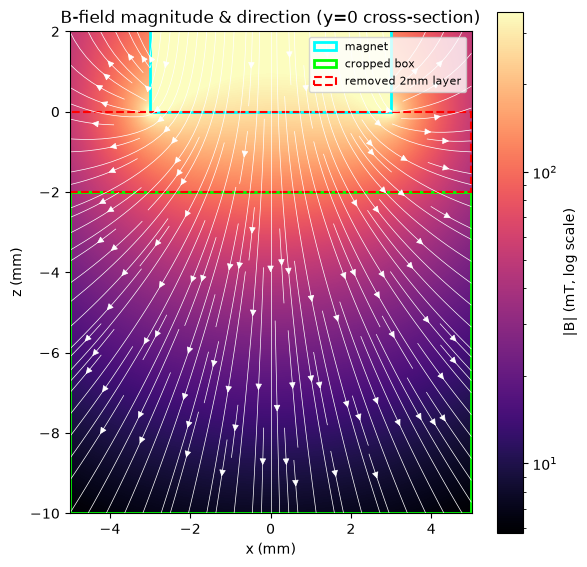

In [6]:

Bx, Bz = B[..., 0], B[..., 2]
Bmag = np.linalg.norm(B, axis=-1)

fig, ax = plt.subplots(figsize=(6, 6))
pcm = ax.pcolormesh(Xs, Zs, Bmag, shading="auto", cmap="magma",
                     norm=plt.matplotlib.colors.LogNorm(vmin=max(Bmag.min(), 1e-2), vmax=Bmag.max()/2))
fig.colorbar(pcm, ax=ax, label="|B| (mT, log scale)")

ax.streamplot(Xs, Zs, Bx, Bz, color='white', density=1.5, linewidth=0.5, arrowsize=1.0)


ax.add_patch(plt.Rectangle((-3, 0), 6, 6, fill=False, edgecolor="cyan", linewidth=2, label="magnet"))
ax.add_patch(plt.Rectangle((-5, Z_BOT), 10, Z_TOP - Z_BOT, fill=False, edgecolor="lime", linewidth=2, label="cropped box"))
ax.add_patch(plt.Rectangle((-5, Z_TOP), 10, -Z_TOP, fill=False, edgecolor="red", linestyle="--", linewidth=1.5, label="removed 2mm layer"))

ax.set_xlabel("x (mm)"); ax.set_ylabel("z (mm)")
ax.set_title("B-field magnitude & direction (y=0 cross-section)")
ax.legend(loc="upper right", fontsize=8)
ax.set_aspect("equal")
fig.tight_layout()
plt.show()


In [7]:
np.min(Bmag)

np.float64(5.786073114758688)

In [8]:
nx_interp, nz_interp = 51, 91
x_interp_line = np.linspace(0, 10, nx_interp)
z_interp_line = np.linspace(-20, -0.5, nz_interp)   # small margin above to show the magnet & cropped-out layer
Xs_interp, Zs_interp = np.meshgrid(x_interp_line, z_interp_line, indexing='ij')
pts = np.stack([Xs_interp.ravel(), np.zeros_like(Xs_interp.ravel()), Zs_interp.ravel()], axis=-1)

B_for_pts = magnet.getB(pts).reshape(nx_interp, nz_interp, 3)

B_interpolator = scipy.interpolate.RegularGridInterpolator((x_interp_line, z_interp_line), B_for_pts, method='cubic', bounds_error=True)


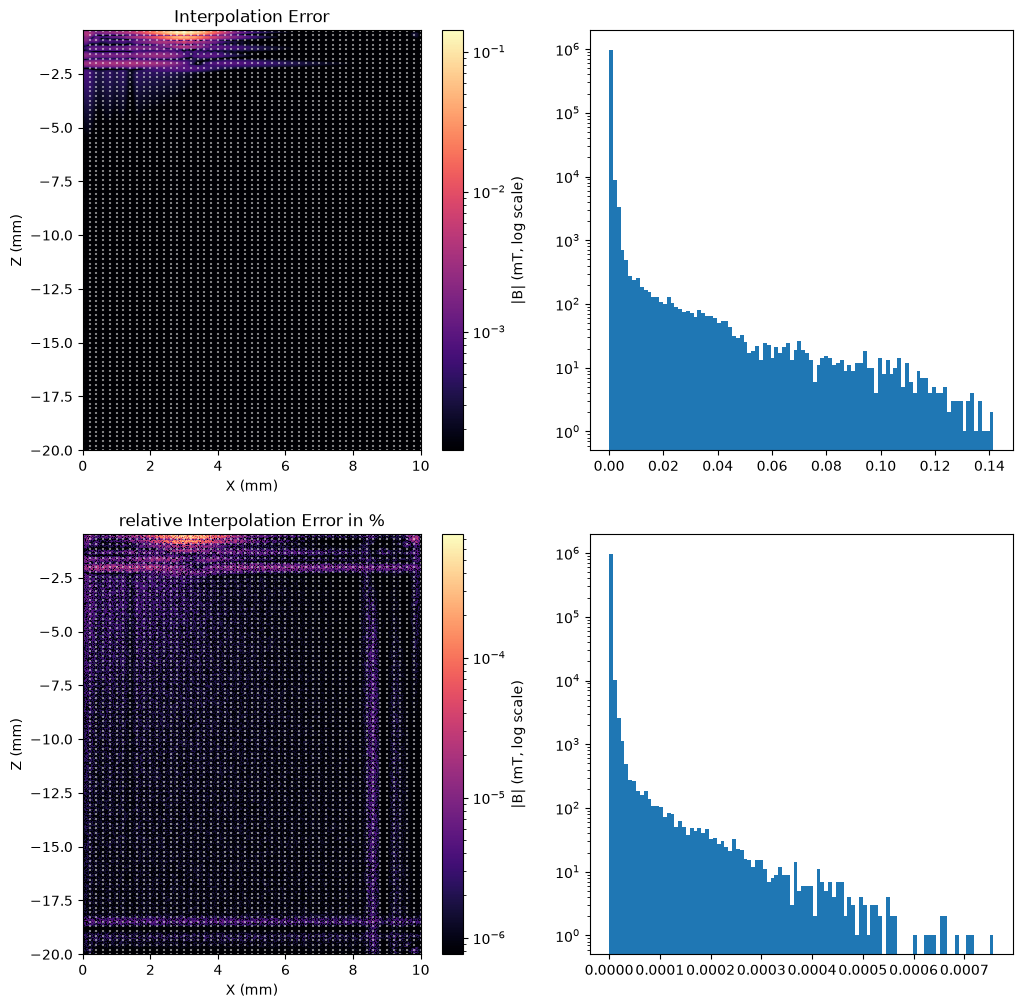

In [9]:
test_x_line = np.linspace(x_interp_line[0], x_interp_line[-1], 1000)
test_z_line = np.linspace(z_interp_line[0], z_interp_line[-1], 1000)    
test_X, test_Y = np.meshgrid(test_x_line, test_z_line, indexing='ij')

B_interp = B_interpolator((test_X, test_Y)).reshape(1000, 1000, 3)
B_truth  = magnet.getB(np.stack([test_X.ravel(), np.zeros_like(test_X.ravel()), test_Y.ravel()], axis=-1)).reshape(1000, 1000, 3)

interp_error = B_interp - B_truth
error_mag = np.linalg.norm(interp_error, axis=-1)

interp_error_rel = 100 % np.divide(np.linalg.norm(interp_error, axis=-1), np.linalg.norm(B_truth, axis=-1), out=np.zeros_like(error_mag), where=np.linalg.norm(B_truth, axis=-1)!=0)



fig, ax = plt.subplots(2, 2, figsize=(12, 12))
pcm = ax[0, 0].pcolormesh(test_X, test_Y, error_mag, shading="auto", cmap="magma",
                        norm=plt.matplotlib.colors.LogNorm(vmin=error_mag.min() + 0.001 * error_mag.max(), vmax=error_mag.max()))
ax[0, 0].scatter(Xs_interp, Zs_interp, s=1, color='white', marker='+', alpha=0.5)
ax[0, 0].set_title("Interpolation Error")
ax[0, 0].set_xlabel("X (mm)")
ax[0, 0].set_ylabel("Z (mm)")
ax[0, 1].hist(error_mag.ravel(), bins=100, log=True)
fig.colorbar(pcm, label="|B| (mT, log scale)")

pcm = ax[1, 0].pcolormesh(test_X, test_Y, interp_error_rel, shading="auto", cmap="magma",
                          norm=plt.matplotlib.colors.LogNorm(vmin=interp_error_rel.min() + 0.001 * interp_error_rel.max(), vmax=interp_error_rel.max()))
ax[1, 0].scatter(Xs_interp, Zs_interp, s=1, color='white', marker='+', alpha=0.5)
ax[1, 0].set_title("relative Interpolation Error in %")
ax[1, 0].set_xlabel("X (mm)")
ax[1, 0].set_ylabel("Z (mm)")
ax[1, 1].hist(interp_error_rel.ravel(), bins=100, log=True)

fig.colorbar(pcm, label="|B| (mT, log scale)")

plt.show()

In [10]:
def hex_array_2d(arr):
    lines = []
    for row in arr:
        point_strings = []
        for point in row:
            point_string = f"Vec2( {point[0].hex()}f, {point[1].hex()}f )"
            point_strings.append(point_string)
        row_string = ", ".join(point_strings)
        lines.append("{" + row_string + "}")
    return "{\n" + ",\n".join(lines) + "\n}"

field_2d = B_for_pts.swapaxes(0, 1)[:, :, (0, 2)]
arr = hex_array_2d(field_2d)

constructor = """
#pragma once
#include "BicubicField.h"

using Vec2 = Eigen::Vector2f;
struct Point { float r; float z; };

""" + f"""
constexpr int NR = {nx_interp};
constexpr int NZ = {nz_interp};

constexpr Point BICUBIC_ORIGIN = {{ {x_interp_line[0] }, {z_interp_line[0] } }};
constexpr Point BICUBIC_FAR    = {{ {x_interp_line[-1]}, {z_interp_line[-1]} }};

inline const Vec2 BICUBIC_INTERPOLATION_TABLE[NZ][NR] = {arr};
"""


with open("../firmware/include/magnet_model/magnet_model_table.h", mode="w") as file:
    file.write(constructor)

# print(constructor)
